In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
from matplotlib.legend_handler import HandlerPatch


################################################
# Skeleton code for Homework 4 Question 1
# MAE 6870 Engineering Collective Intelligence
# Cornell University, Fall 2025
# Prof. Anastasia Bizyaeva
#################################################

# ==============================
# Utilities
# ==============================
def circle_points(n, radius):
    """Equally spaced points on a circle (counterclockwise) in R^2."""
    angles = np.linspace(0, 2*np.pi, n, endpoint=False)
    xy = np.stack([radius*np.cos(angles), radius*np.sin(angles)], axis=1)
    return xy

def antipodal_goals(x0):
    """Goal for agent i is the antipode of its initial position (i+N/2 mod N)."""
    n = x0.shape[0]
    assert n % 2 == 0, "Antipodal swap needs an even number of robots."
    perm = [(i + n//2) % n for i in range(n)]
    goals = x0[perm].copy()
    return goals

def unit_vector(v, eps=1e-9):
    nrm = np.linalg.norm(v)
    return v / max(nrm, eps)

def nominal_velocity(x, g, vmag):
    """Straight-line constant-speed nominal velocity from x to g."""
    d = g - x
    d_norm = np.linalg.norm(d)
    if d_norm < 1e-9:
        return np.zeros(2)
    return vmag * d / d_norm

def pairwise_cbf_halfspaces_for_agent(i, X, U_nom, dmin, alpha):
    """
    Build half-space constraints A u_i >= b for agent i:
      2 (p_i - p_j)^T u_i >= -alpha h_ij + 2 (p_i - p_j)^T u_j_nom
      with h_ij = ||p_i - p_j||^2 - dmin^2.
    Returns A (k x 2), b (k,), one row per neighbor j.
    """
    pi = X[i]
    Ai = []
    bi = []
    for j in range(X.shape[0]):
        if j == i:
            continue
        pj = X[j]
        dij = pi - pj
        h_ij = np.dot(dij, dij) - dmin**2
        a = 2.0 * dij                      # row vector acting on u_i
        rhs = -alpha * h_ij + 2.0 * np.dot(dij, U_nom[j])
        Ai.append(a)
        bi.append(rhs)
    if len(Ai) == 0:
        return np.zeros((0,2)), np.zeros((0,))
    return np.vstack(Ai), np.array(bi)

def project_onto_halfspace(u, a, c):
    """
    Project u onto {x | a^T x >= c}. Closed-form Euclidean projection.
    If a^T u >= c, return u. Else return u + ((c - a^T u)/||a||^2) a.
    """
    at_u = float(a @ u)
    if at_u >= c:
        return u
    a_norm2 = float(a @ a)
    if a_norm2 < 1e-12:
        return u  # degenerate
    return u + ((c - at_u) / a_norm2) * a

def project_u_nom_via_dykstra(u0, A, b, max_cycles=20):
    """
    Dykstra-style cyclic projections onto half-spaces A_k u >= b_k.
    Returns the Euclidean projection of u0 onto the intersection (good approx in few cycles).
    """
    u = u0.copy()
    # Dykstra corrections, one per constraint
    R = np.zeros_like(A)
    if A.shape[0] == 0:
        return u
    for _ in range(max_cycles):
        for k in range(A.shape[0]):
            a = A[k]
            c = b[k]
            y = u + R[k]
            u_new = project_onto_halfspace(y, a, c)
            R[k] = y - u_new
            u = u_new
    return u

def clamp_speed(u, vmax): # imposes a speed limit 
    nrm = np.linalg.norm(u)
    if nrm <= vmax:
        return u
    return (vmax / nrm) * u








# --- custom handler that draws a circle inside the legend box ---
def _legend_circle(legend, orig_handle, xdescent, ydescent, width, height, fontsize):
    cx = xdescent + width/2.0
    cy = ydescent + height/2.0
    r  = 0.45 * min(width, height)
    return mpatches.Circle((cx, cy), r,
                           fill=False,
                           linestyle=orig_handle.get_linestyle(),
                           edgecolor=orig_handle.get_edgecolor(),
                           linewidth=orig_handle.get_linewidth())



In [68]:
np.zeros((N,N))

array([[0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0.]])

In [69]:
a = np.array([1,2])
b = np.array([3,4])
np.stack((a,b)).T

array([[1, 3],
       [2, 4]])

In [70]:

# ==============================
# Scenario and model parameters
# ==============================
N = 8                     # number of robots
R_circle = 6.0             # initial/goal circle radius
v_nom = 0.8                # nominal constant speed (m/s)
dt = 0.05                  # time step (s)
T_max = 30.0               # max sim time (s)
goal_tol = 0.01            # stop when all within this distance to goal (m)

# Robot geometry & CBF safety
robot_radius = 0.50        # disk radius (m)
safety_margin = 0.2        # extra cushion (m)
d_min = 2.0*robot_radius + safety_margin   # minimum allowed center-to-center distance
alpha = 2.0                # CBF class-K slope (1/s)

# Deadlock tie-breaker (set to 0.0 to disable)
bias_strength = 0.00       # m/s magnitude of small orthogonal bias

# ==============================
# Set up initial/goal states
# ==============================
X0 = circle_points(N, R_circle)       # (N,2)
G  = antipodal_goals(X0)              # (N,2)
X  = X0.copy()
traj = [X.copy()]
Us = []

# ==============================
# Simulation loop
# ==============================
t = 0.0
t_lst = [t]
num_steps = int(np.ceil(T_max / dt))
with_cbf = True   # toggle to False to see the (colliding) nominal behavior

for step in range(num_steps):
    # Stop if all goals reached
    if np.all(np.linalg.norm(G - X, axis=1) <= goal_tol):
        break
    # Nominal velocities
    U_nom = np.zeros_like(X)
    for i in range(N):
        U_nom[i] = nominal_velocity(X[i], G[i], v_nom) 

    # CBF filtering (decentralized; each agent uses others' U_nom as u_j)
    if with_cbf:
        U = np.zeros_like(X)
        for i in range(N):
            A_i, b_i = pairwise_cbf_halfspaces_for_agent(i, X, U_nom, d_min, alpha)
            u_proj = project_u_nom_via_dykstra(U_nom[i], A_i, b_i, max_cycles=25)
            U[i] = clamp_speed(u_proj, v_nom)  # keep same speed cap
    else:
        U = U_nom

    # Integrate
    X = X + dt * U
    traj.append(X.copy())
    Us.append(U.copy())
    t += dt
    t_lst.append(t)

traj = np.stack(traj, axis=0)  # (T, N, 2)
Us = np.stack(Us, axis=0)
print(f"Simulated {traj.shape[0]} steps, final mean goal error:",
      np.mean(np.linalg.norm(G - X, axis=1)))

Simulated 601 steps, final mean goal error: 7.780580189071508


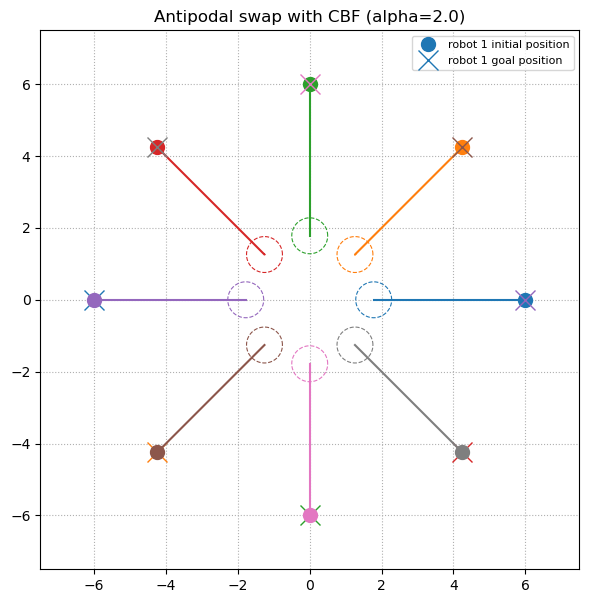

In [71]:
# Visualization
plot_every = 2             # draw every k steps (for speed)
trail_len = traj.shape[0]            # number of past positions to show per agent

# ==============================
# Plot
# ==============================
colors = plt.cm.tab10(np.arange(N) % 10)
fig, ax = plt.subplots(figsize=(7,7))
ax.set_aspect('equal', adjustable='box')
ax.set_xlim(-R_circle-1.5, R_circle+1.5)
ax.set_ylim(-R_circle-1.5, R_circle+1.5)
ax.set_title(f"Antipodal swap with {'CBF' if with_cbf else 'no CBF'} (alpha={alpha})")

# draw safety disks at final positions (for visualization)
theta = np.linspace(0, 2*np.pi, 60)
circle = np.stack([np.cos(theta), np.sin(theta)], axis=1)

for i in range(N):
    # trail
    tt = traj[-trail_len:, i, :]
    ax.plot(tt[:,0], tt[:,1], lw=1.5, color=colors[i])
    # start and goal
    ax.plot(X0[i,0], X0[i,1], 'o', color=colors[i], ms=10, label=f"robot {i+1} initial position" if i==0 else None)
    ax.plot(G[i,0],  G[i,1],  'x', color=colors[i], ms=15,label=f"robot {i+1} goal position" if i==0 else None)
    # final disk
    circ = X[i] + robot_radius*circle  #+ d_min/2.0 * circle  # half of d_min is visual buffer; true body radius is robot_radius
    ax.plot(circ[:,0], circ[:,1], '--', color=colors[i], lw=0.8)



ax.legend(loc='upper right', frameon=True, fontsize=8)


ax.grid(True, ls=':')
plt.show()


In [72]:
np.shape(np.asarray(Us))


(600, 8, 2)

In [73]:
np.shape(np.asarray(traj))

(601, 8, 2)

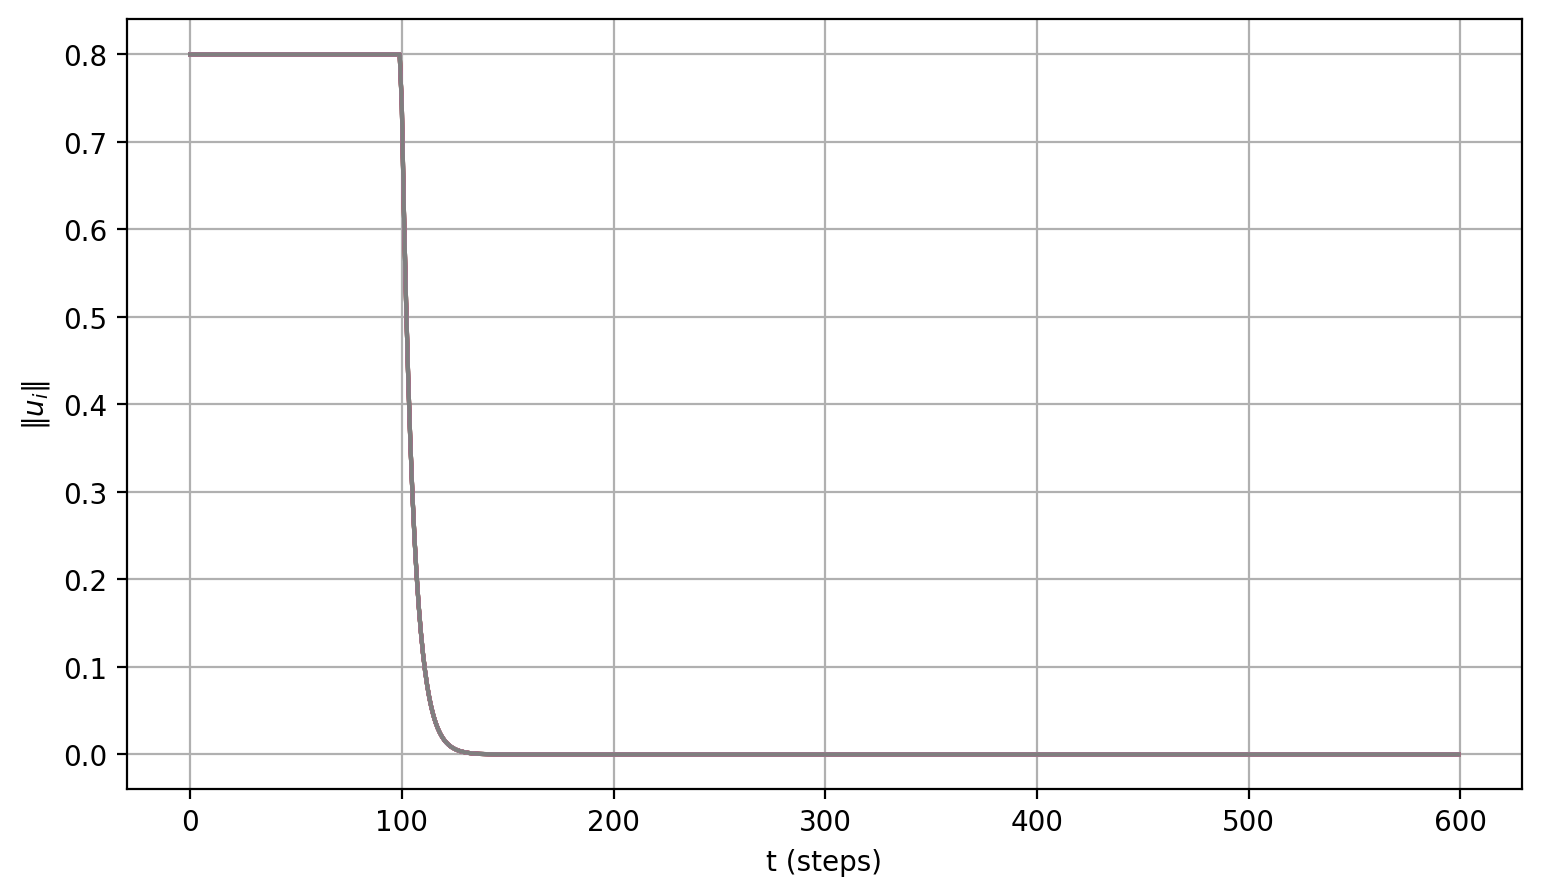

In [74]:
fig, ax = plt.subplots(figsize=(9,5),dpi = 200)
#ax.set_aspect('equal', adjustable='box')
#ax.set_xlim(-R_circle-1.5, R_circle+1.5)
#ax.set_ylim(-R_circle-1.5, R_circle+1.5)
#ax.set_title(f"Antipodal swap with {'CBF' if with_cbf else 'no CBF'} (alpha={alpha})")
ax.set_xlabel("t (steps)")
ax.set_ylabel(r"$\|u_i\|$")
ax.grid()


for i in range(N):
    tt = Us[:, i ,:]
    ax.plot(np.linalg.norm(Us[:, i ,:],axis = 1))

In [75]:
d

array([1., 1., 1., 1., 1., 1., 1., 1.])

In [84]:
def compute_attention_and_bias(p, u_qp, A, nu_low, nu_high, v_th, kI, p_center):
    N = len(p)

    nu_t = np.zeros(N)
    I_t = np.zeros(N)
    s = np.zeros((N, N), float)

    vbar = np.mean([np.linalg.norm(u_qp[i]) for i in range(N)])

    for i in range(N):
        nu_t[i] = nu_low if vbar > v_th else nu_high

        ni = unit_vector(p[i] - p_center)
        bi = np.array([[0, -1], [1, 0]]) @ ni

        for j in range(N):
            s[i, j] = np.linalg.det(np.stack([bi, p[i] - p[j]]).T)

    for i in range(N):
        nileft = np.sum(s[i] > 0)
        niright = np.sum(s[i] < 0)
        I_t[i] = kI * (niright - nileft)

    return nu_t, I_t


def update_opinion_state(x, A, d, nu_t, I, dt):
    new_x = x.copy()
    N = len(x)
    for i in range(N):
        new_x[i] = (x[i]+ dt * (-d[i] * x[i]+ np.tanh( nu_t[i] * (A[i, i] * x[i] + sum(A[i, j] * x[j] for j in range(N))))+ I[i]))
    return new_x

def compute_nominal_control_with_NOD(p,p_star, x, p_center, k, beta):
    #b = np.zeros_like(p)
    U = np.zeros_like(p)
    for i in range(N):
    
        ni = unit_vector(p[i]-p_center)
        bi = np.array([[0,-1],[1,0]])@ni
        U[i] -k*(p[i] - p_star[i]) + beta*x[i]*bi
    return U

In [85]:
X0 = circle_points(N, R_circle)       # (N,2)
G  = antipodal_goals(X0)              # (N,2)
X  = X0.copy()
traj = [X.copy()]
Us = []


x_op = np.zeros(N)
nu_low = 0.1
nu_high = 2
kI = 1
v_th = 0.1
A = np.ones((N,N)) - np.diag(np.ones(N))
p_center = np.array([0,0])
k=1
beta=1
d = np.ones(N)

# ==============================
# Simulation loop
# ==============================
t = 0.0
t_lst = [t]
num_steps = int(np.ceil(T_max / dt))
with_cbf = True   # toggle to False to see the (colliding) nominal behavior

for step in range(num_steps):
    # Stop if all goals reached
    if np.all(np.linalg.norm(G - X, axis=1) <= goal_tol):
        break
    # Nominal velocities
    U_nom = np.zeros_like(X)
    for i in range(N):
        U_nom[i] = nominal_velocity(X[i], G[i], v_nom) 

    # CBF filtering (decentralized; each agent uses others' U_nom as u_j)
    if with_cbf:
        U = np.zeros_like(X)
        for i in range(N):
            A_i, b_i = pairwise_cbf_halfspaces_for_agent(i, X, U_nom, d_min, alpha)
            u_proj = project_u_nom_via_dykstra(U_nom[i], A_i, b_i, max_cycles=25)
            U[i] = clamp_speed(u_proj, v_nom)  # keep same speed cap
    else:
        U = U_nom

    nu_t, I_t = compute_attention_and_bias(X,U, A, nu_low, nu_high, v_th, kI, p_center)
    x_op  = update_opinion_state(x_op, A, d, nu_t, I_t, dt)
    U_nom = compute_nominal_control_with_NOD(X,G, x_op, p_center, k, beta)
    # Integrate

    if with_cbf:
        U = np.zeros_like(X)
        for i in range(N):
            A_i, b_i = pairwise_cbf_halfspaces_for_agent(i, X, U_nom, d_min, alpha)
            u_proj = project_u_nom_via_dykstra(U_nom[i], A_i, b_i, max_cycles=25)
            U[i] = clamp_speed(u_proj, v_nom)  # keep same speed cap
    else:
        U = U_nom

    X = X + dt * U
    traj.append(X.copy())
    Us.append(U.copy())
    t += dt
    t_lst.append(t)

traj = np.stack(traj, axis=0)  # (T, N, 2)
Us = np.stack(Us, axis=0)
print(f"Simulated {traj.shape[0]} steps, final mean goal error:",
      np.mean(np.linalg.norm(G - X, axis=1)))

Simulated 601 steps, final mean goal error: 12.0


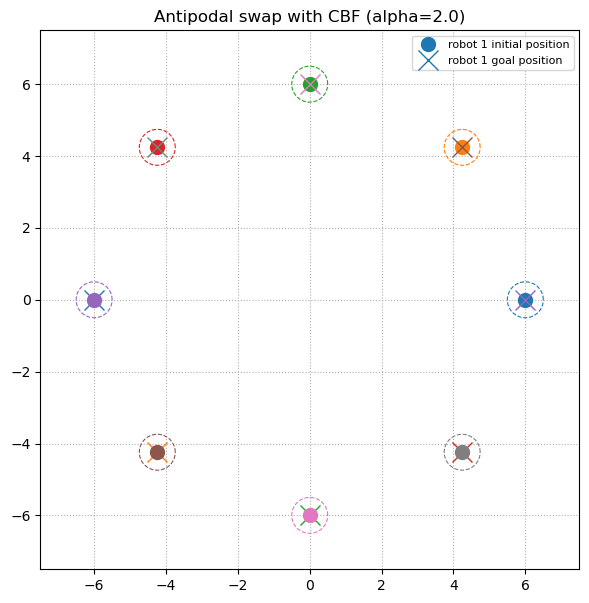

In [86]:
# Visualization
plot_every = 2             # draw every k steps (for speed)
trail_len = traj.shape[0]            # number of past positions to show per agent

# ==============================
# Plot
# ==============================
colors = plt.cm.tab10(np.arange(N) % 10)
fig, ax = plt.subplots(figsize=(7,7))
ax.set_aspect('equal', adjustable='box')
ax.set_xlim(-R_circle-1.5, R_circle+1.5)
ax.set_ylim(-R_circle-1.5, R_circle+1.5)
ax.set_title(f"Antipodal swap with {'CBF' if with_cbf else 'no CBF'} (alpha={alpha})")

# draw safety disks at final positions (for visualization)
theta = np.linspace(0, 2*np.pi, 60)
circle = np.stack([np.cos(theta), np.sin(theta)], axis=1)

for i in range(N):
    # trail
    tt = traj[-trail_len:, i, :]
    ax.plot(tt[:,0], tt[:,1], lw=1.5, color=colors[i])
    # start and goal
    ax.plot(X0[i,0], X0[i,1], 'o', color=colors[i], ms=10, label=f"robot {i+1} initial position" if i==0 else None)
    ax.plot(G[i,0],  G[i,1],  'x', color=colors[i], ms=15,label=f"robot {i+1} goal position" if i==0 else None)
    # final disk
    circ = X[i] + robot_radius*circle  #+ d_min/2.0 * circle  # half of d_min is visual buffer; true body radius is robot_radius
    ax.plot(circ[:,0], circ[:,1], '--', color=colors[i], lw=0.8)



ax.legend(loc='upper right', frameon=True, fontsize=8)


ax.grid(True, ls=':')
plt.show()
